# Emotion Detection Notebook
CNN-based model with Smart Greeting Feature

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plta
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [3]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'dataset', 'Emotion_Detection')

IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 10

print('Dataset folders:', os.listdir(DATA_DIR))

Dataset folders: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

class_names = train_ds.class_names
print('Classes:', class_names)

Found 2088 files belonging to 7 classes.
Using 1671 files for training.
Found 2088 files belonging to 7 classes.
Using 417 files for validation.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [6]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.1658 - loss: 1.9460 - val_accuracy: 0.1655 - val_loss: 1.9443
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.1652 - loss: 1.9400 - val_accuracy: 0.1823 - val_loss: 1.9262
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2172 - loss: 1.8811 - val_accuracy: 0.2854 - val_loss: 1.8415
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2490 - loss: 1.8412 - val_accuracy: 0.3022 - val_loss: 1.7913
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.2825 - loss: 1.7897 - val_accuracy: 0.3165 - val_loss: 1.7490
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3040 - loss: 1.7653 - val_accuracy: 0.3285 - val_loss: 1.7602
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3160 - loss: 1.7169 - val_accuracy: 0.3501 - val_loss: 1.6876
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.3537 - loss: 1.6680 - val_accuracy: 0.3597 - v

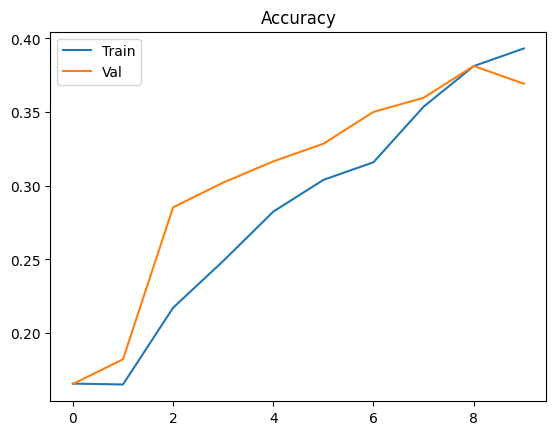

In [9]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title('Accuracy')
plt.show()

In [10]:
model.save('emotion_model.h5')
print('Model saved!')

Model saved!


In [11]:
emotion_messages = {
    'happy': 'Great to see you happy!',
    'sad': 'Hope your day gets better.',
    'angry': 'Take a deep breath and stay calm.',
    'neutral': 'Have a productive day.',
    'surprise': 'Hope everything is going well.',
    'fear': 'Stay confident.',
    'disgust': 'Hope things improve soon.'
}

def smart_greeting(emotion):
    return emotion_messages.get(emotion, 'Welcome')

print(smart_greeting('happy'))

Great to see you happy!


In [12]:

# import tensorflow as tf
# print(tf.__version__)
